# 군집 알고리즘

## 과일 사진 데이터 준비하기
- 사과, 바나나, 파인애플을 담고 있는 흑백사진 300장
- 넘파이 배열의 기본저장 포맷인 npy 파일로 저장

In [1]:
# 코랩에서 fruits_300.npy  다운로드

#!wget https://bit.ly/fruits_300 -O fruits_300.npy

# ! : 코랩은 이후 명령을 파이썬 코드가 아닌 리눅스 셀 명령으로 이해
# wget는 웹(Web)에서 파일을 다운로드하는 명령어
# --> -0 옵션을 사용하여 파일이름 지정

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 넘파이에서 npy 파일을 로드

fruits = np.load('fruits_300.npy')

In [4]:
print(fruits.shape)

# (300, 100, 100)  : 갯수, 이미지 높이, 이미지 너비

(300, 100, 100)


In [5]:
# 첫번째 이미지의 첫번째 행을 출력

print(fruits[0, 0, :])

# 각 값 : 0 ~ 255

[  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   2   1
   2   2   2   2   2   2   1   1   1   1   1   1   1   1   2   3   2   1
   2   1   1   1   1   2   1   3   2   1   3   1   4   1   2   5   5   5
  19 148 192 117  28   1   1   2   1   4   1   1   3   1   1   1   1   1
   2   2   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1
   1   1   1   1   1   1   1   1   1   1]


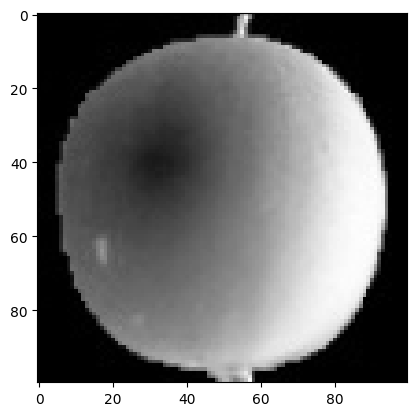

In [6]:
# 맷플롯립의 imshow() 함수를 사용하면 배열에 저장된 이미지를 출력
# 첫번째 이미지 : fruits[0]

plt.imshow(fruits[0], cmap='gray')
plt.show()

# 0에 가까울수록 검게, 높은값은 밝게

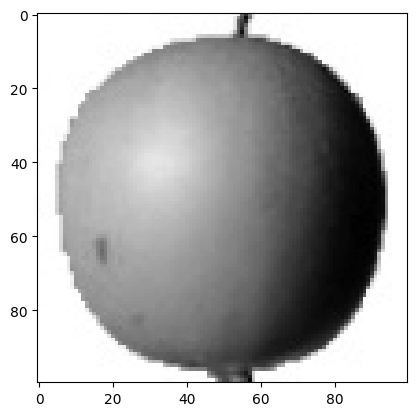

In [7]:
# 바탕이 검게 나오므로 보기가 좋지 않네요
# cmap='gray_r' : 반전
# 밝은 부분이 0에 가깝고, 짙은 부분은 255에 가깝다

plt.imshow(fruits[0], cmap='gray_r')
plt.show()

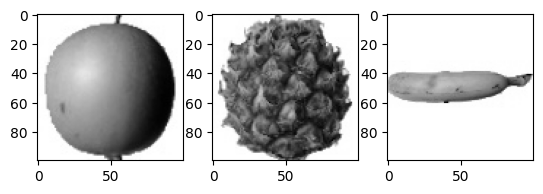

In [8]:
# 사과, 바나나, 파인애플 이미지 출력
# 각각 100 개씩 들어 있음

fig, axs = plt.subplots(1, 3)
axs[0].imshow(fruits[0], cmap='gray_r')
axs[1].imshow(fruits[100], cmap='gray_r')
axs[2].imshow(fruits[200], cmap='gray_r')
plt.show()

## 픽셀 값 분석하기

In [9]:
# 이미지 하나 : 100*100
# 100*100 : 이미지를 펼쳐서 길이가 10,000 인 1차원 배열로 만듬
# -> 이미지로 출력하긴 어렵지만, 배열을 계산할 때 편리

apple = fruits[0:100].reshape(-1, 100*100)
pineapple = fruits[100:200].reshape(-1, 100*100)
banana = fruits[200:300].reshape(-1, 100*100)

In [10]:
# 100개 이미지 : 하나의 이미지 배열
print(apple.shape)

(100, 10000)


In [11]:
# 이미지별 픽셀의 평균값 계산
#  axis=1 : 두번째 축인 열을 따라 계산

print(apple.mean(axis=1))

#print(len(apple.mean(axis=1)))
# 첫번째이미지 픽셀 평균값, 두번째 이미지 픽셀 평균값

[ 88.3346  97.9249  87.3709  98.3703  92.8705  82.6439  94.4244  95.5999
  90.681   81.6226  87.0578  95.0745  93.8416  87.017   97.5078  87.2019
  88.9827 100.9158  92.7823 100.9184 104.9854  88.674   99.5643  97.2495
  94.1179  92.1935  95.1671  93.3322 102.8967  94.6695  90.5285  89.0744
  97.7641  97.2938 100.7564  90.5236 100.2542  85.8452  96.4615  97.1492
  90.711  102.3193  87.1629  89.8751  86.7327  86.3991  95.2865  89.1709
  96.8163  91.6604  96.1065  99.6829  94.9718  87.4812  89.2596  89.5268
  93.799   97.3983  87.151   97.825  103.22    94.4239  83.6657  83.5159
 102.8453  87.0379  91.2742 100.4848  93.8388  90.8568  97.4616  97.5022
  82.446   87.1789  96.9206  90.3135  90.565   97.6538  98.0919  93.6252
  87.3867  84.7073  89.1135  86.7646  88.7301  86.643   96.7323  97.2604
  81.9424  87.1687  97.2066  83.4712  95.9781  91.8096  98.4086 100.7823
 101.556  100.7027  91.6098  88.8976]


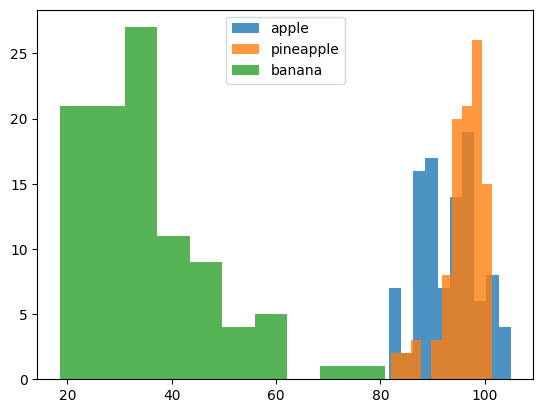

In [12]:
# 각 샘플 100 개에 대한 평균값을 히스토그램으로 시각화

plt.hist(np.mean(apple, axis=1), alpha=0.8)
plt.hist(np.mean(pineapple, axis=1), alpha=0.8)
plt.hist(np.mean(banana, axis=1), alpha=0.8)

plt.legend(['apple', 'pineapple', 'banana'])  # 범례
plt.show()

# 바나나는 평균값이 40 아래에 집중되어 있다.
# 사과, 파인애플의 평균값은 90~100 사이에 집중

# 픽셀 평균값으로 바나나 / 사과, 파인애플 구분 가능
# -> 바나나는 사진에서 차지하는 영역이 작기 때문에 평균값도 작다

# 사과, 파인애플은 겹쳐있어서 픽셀값만으로는 구분하기 어렵다
# -> 대체로 형태로 동그랗고, 사진이 차지하는 크기도 비슷


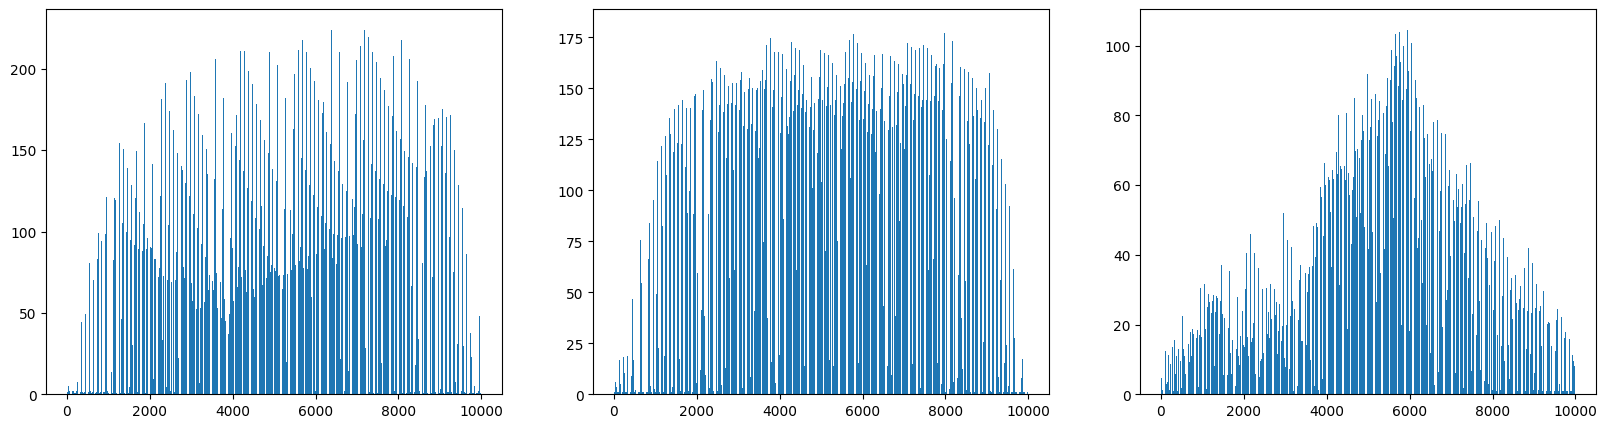

In [13]:
# 좀 더 나은 방법 ?
# -> 샘플의 평균값이 아니고 픽셀별 평균값을 비교
# -> 전체 샘플에 대한 각 픽셀의 평균을 계산
# -> 세 과일은 모양이 다르므로 픽셀값이 높은 위치가 조금 다를 것 같습니다.

# 픽셀 평균의 막대그래프 : 시간 조금 걸임

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].bar(range(10000), np.mean(apple, axis=0))
axs[1].bar(range(10000), np.mean(pineapple, axis=0))
axs[2].bar(range(10000), np.mean(banana, axis=0))
plt.show()

# 3개의 그래프를 보면 과일마다 값이 높은 구간이 다른다
# -> 사과는 사진 아래쪽으로 갈수록 값이 높아지고
# -> 파인애플은 비교적 고르면서 높다
# -> 바나나는 확실히 중아의 픽셀값이 높다

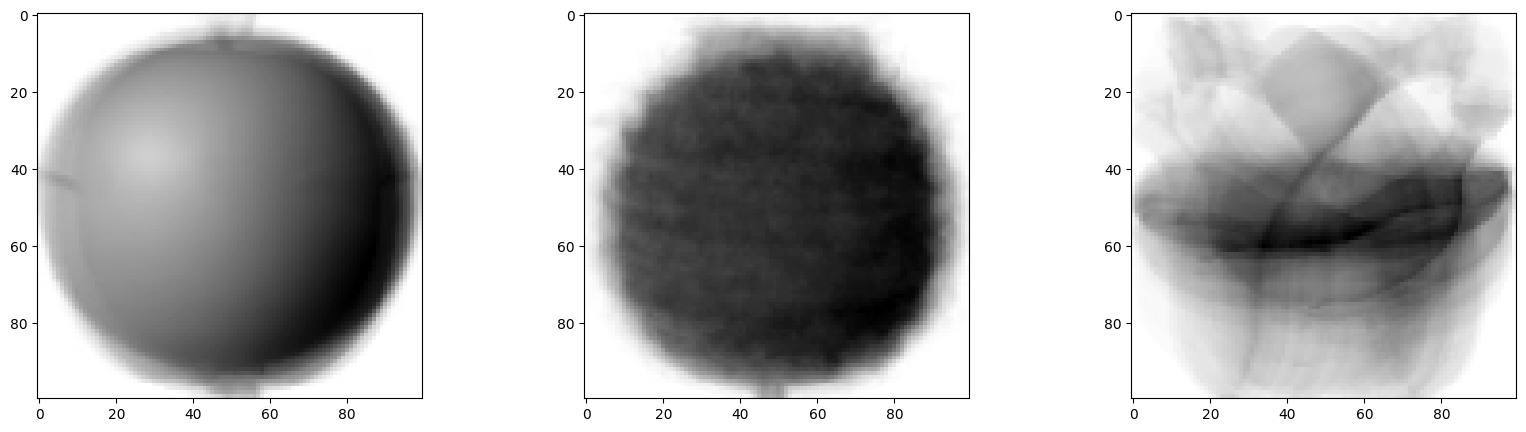

In [14]:
# 평균 이미지 그리기

# 픽셀 평균값을 100*100 바꿔서 2차원 배열로 바꿔서 이미지처럼 출력
apple_mean = np.mean(apple, axis=0).reshape(100, 100)
pineapple_mean = np.mean(pineapple, axis=0).reshape(100, 100)
banana_mean = np.mean(banana, axis=0).reshape(100, 100)

# imshow() 함수를 사용하면 배열에 저장된 값을 이미지로 출력
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(apple_mean, cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean, cmap='gray_r')
plt.show()

## 평균값과 가까운 사진 고르기

In [15]:
# 위의 대표 이미지와 가까운 사진을 골라낸다면 사과, 파인애플, 바나나를 구분할 수 있지않을까요?

# 사과 사진의 평균값인  apple_mean과 가장 가까운 사진을 골라보죠.
# 절대값 오차 : fruits 배열에 있는 모든 샘플에서 apple_mean 을 뺀 절대값의 평균을 계산

abs_diff = np.abs(fruits - apple_mean)   # np.absoute() 다른 이름 / (300,100,100) 크기의 배열
abs_mean = np.mean(abs_diff, axis=(1,2)) # / (300,100,100) 크기의 배열
print(abs_mean.shape)  # abs_mean 은 각 샘플의 오차 평균이므로 (300, ) 인 1차원 배열
# print(abs_mean)

(300,)


In [16]:
# abs_mean과 오차가 가장 작은 샘플 100개를 골라보자
# np.argsort() 함수는 작은 것에서 큰 순서대로 나열한 abs_mean 배열의 인덱스를 반환한다.
# 이중에서 처음 100를 선택

apple_index = np.argsort(abs_mean)[:100]  # 오름차순 정렬 후 100개 선택

apple_index

array([33, 48, 70, 57, 87, 12, 78, 59,  1, 74, 86, 38, 50, 92, 69, 27, 68,
       30, 66, 24, 76, 98, 15, 84, 47, 90,  3, 94, 53, 23, 14, 71, 32,  7,
       73, 36, 55, 77, 21, 10, 17, 39, 99, 95, 11, 35, 65,  6, 61, 22, 56,
       89,  2, 13, 80,  0, 97,  4, 58, 34, 40, 43, 75, 82, 54, 16, 31, 49,
       93, 37, 63, 64, 41, 28, 67, 25, 96,  8, 83, 46, 19, 79, 72,  5, 85,
       29, 20, 60, 81,  9, 45, 51, 88, 62, 91, 26, 52, 18, 44, 42])

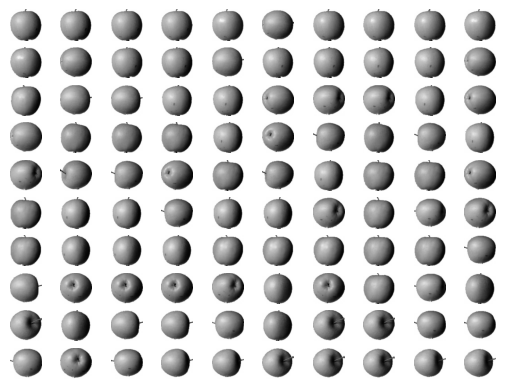

In [17]:
apple_index = np.argsort(abs_mean)[:100]  # 오름차순 정렬 후 100개 선택

# 10 * 10 격자로 이루어진 그래프를 그리자
fig, axs = plt.subplots(10, 10)  # figsize(8,6) 기본
for i in range(10):
    for j in range(10):
        axs[i, j].imshow(fruits[apple_index[i*10 + j]], cmap='gray_r')
        axs[i, j].axis('off')  # 깔끔한 이미지만 그리기 위해 좌표축을 그리지 않는다
plt.show()

## 확인문제

In [18]:
# 바나나 100 개 출력



## k-mean 알고리즘
1. 무작위로 k개위 클러스터 중심을 정합니다.
2. 각 샘플에서 가장 가까운 클러스터 중심을 찾아 해당 클러스터의 샘플로 지정합니다.
3. 클러스터에 속한 샘플의 평균값으로 클러스터 중심을 변경합니다.
4. 클러스터 중심에 변화가 없을 때까지 2번으로 돌아가 반복합니다.

In [19]:
# 자료 다운로드
!wget https://bit.ly/fruits_300 -O fruits_300.npy

'wget'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [20]:
# npy 파일을 읽어 넘파이 배열을 준비
# 훈련을 위해 ( 샘플개수, 너비, 높이 ) --> ( 샘플개수, 너비*높이 ) 2차원을 변경

import numpy as np

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

In [21]:
# k-평균 알고리즘은 KMeans 클래스에 구현되어 있음
# n_clusters 속성 : 클러스터의 갯수 지정

from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)  # 객체 생성
km.fit(fruits_2d)    # 훈련

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [22]:
# 다른 클래스 사용법과 비슷하나, 비지도학습이므로 fit() 메소드에 타깃데이터를 사용하지 않는다

print(km.labels_)

# print( len(km.labels_) )

[2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [23]:
# 레이블 0,1,2로 모은 샘플의 갯수를 확인

print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [24]:
# 각 클러스터가 어떤 이미지를 나타냈는지 그림으로 출력
# draw_fruits() 함수 :
# ceil() 함수 : 올림함수

import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
    n = len(arr)     # n은 샘플 개수입니다

    # 한 줄에 10개씩 이미지를 그립니다. 샘플 개수를 10으로 나누어 전체 행 개수를 계산합니다.
    rows = int(np.ceil(n/10))

    # 행이 1개 이면 열 개수는 샘플 개수입니다. 그렇지 않으면 10개입니다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio))
                            # 피겨사이즈 조절
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:      # n 개까지만 그립니다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')  # 깔끔한 이미지만 그리기 위해 좌표축을 그리지 않는다
    plt.show()


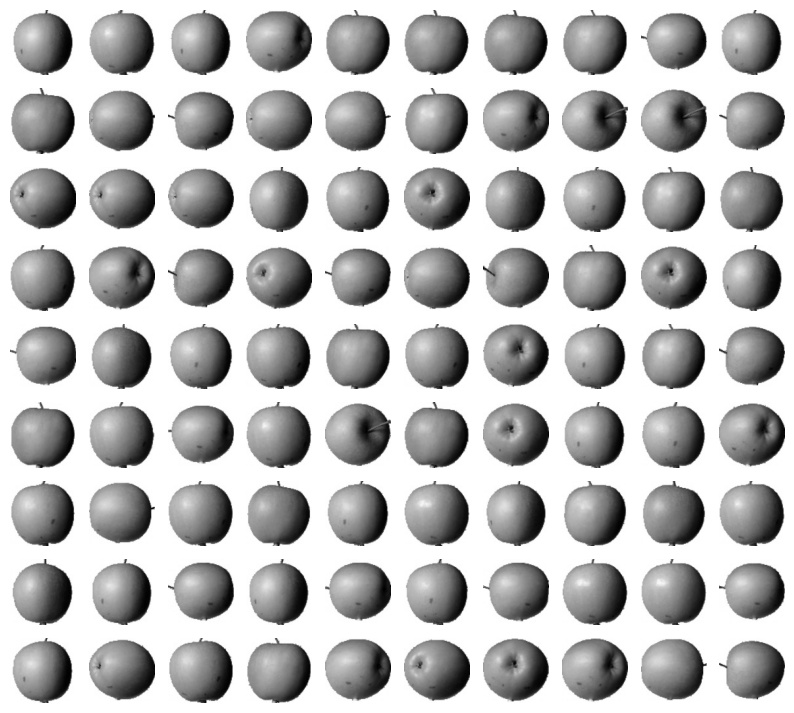

In [25]:
# 함수 호출 : 0, 1, 2
draw_fruits(fruits[km.labels_== 2])

##최적의 k 찾기
- 어떻게 하면 적절한 k를 찾을 수 있을까?
- 적절한 클러스터 개수 찾는 방법 : 엘보우 방법

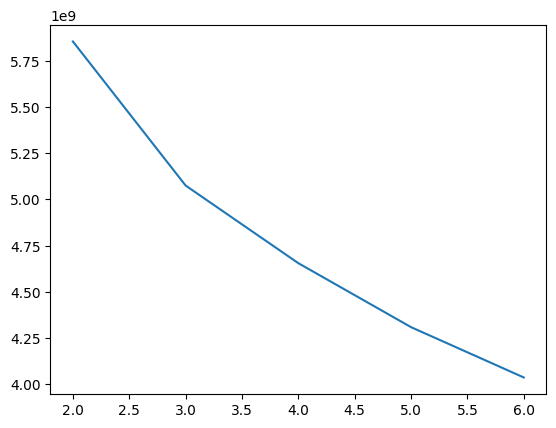

In [26]:
# inertia 이너셔 : 클러스터 중심과 클러스터에 속한 샘플 사이의 거리의 제곱합
# 클러스터 갯수를 증가하면서 이너셔를 그래프로 그리면 이너셔가 감소하는 꺽이는 지점!
# -> 클러스터를 늘려도 밀집도가 개선되지 않는다.
# -> 이지점이 마치 팔꿈치 모양이어서 엘보우 방법이라 한다.
# -> k=3 에서 기울기가 조금 바뀐다. 이 지점이 최적의 k

inertia = []
for k in range(2, 7):  # 임의로 2~6까지 지정해 보자
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(fruits_2d)
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia)
plt.show()